# Thresholds, tails, wind and sensitivity

**CITS4403 Computational Modelling · notebook 03 of 03**

Notebook 02 showed that the arrangement of a fixed treatment budget changes how much burns. This notebook asks the sharper version of the primary research question: does arrangement move the system's **critical point**, or does it only reduce burn size at a fixed distance from it?

It then asks what treatment does to the distribution of fire sizes (SQ3), whether the ranking of arrangements depends on wind (SQ1), and whether any of it survives changing the parameters we fixed by hand.

Every figure comes from the registry in `figures/make_figures.py`; nothing here runs the simulator.

1. [Does treatment move the critical point?](#1.-Does-treatment-move-the-critical-point?)
2. [Burn-size distributions](#2.-Burn-size-distributions)
3. [Wind interaction](#3.-Wind-interaction)
4. [Sensitivity](#4.-Sensitivity)
5. [The lattice frame-invariance check](#5.-The-lattice-frame-invariance-check)
6. [Limitations](#6.-Limitations)

**Prerequisites:** `python run.py --exp all`.

In [1]:
%matplotlib inline
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt    # registers the inline renderer for the figures below
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists())
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from figures.make_figures import CAPTIONS, FIGURES

pc = pd.read_parquet(ROOT / "results" / "pc_estimates.parquet")
scale = pd.read_parquet(ROOT / "results" / "exp2_scale.parquet")
fits = pd.read_parquet(ROOT / "results" / "tail_fits.parquet")
print(f"{len(pc)} threshold rows, {len(scale)} per-lattice rows, {len(fits)} tail fits")

28 threshold rows, 9 per-lattice rows, 3 tail fits


## 1. Does treatment move the critical point?

Below a critical fuel density the fire cannot cross the landscape; above it, it can. Experiment 2 measured that density for each treated landscape the same way notebook 01 measured it for the validation case: sweep the fuel density at three lattice sizes with 500 fires per point, light the whole top edge, and find where the spanning curves for the three sizes cross.

A shift in that density is a change in the system's critical point. A reduction in burned area with the critical point unmoved would be a change in amplitude only. These are different claims, and this is the experiment that separates them.

In [2]:
study = pc[(pc.regime == "STUDY") & (pc.method == "fss_crossing") & pc.L.isna() & (pc.kappa == 0)]
baseline = float(study[(study.condition == "none") & (study.b == 0)].p_c.iloc[0])
table = study[np.isclose(study.b, 0.15)][["condition", "p_c", "p_c_stderr"]].copy()
table["shift from untreated"] = (table.p_c - baseline).round(4)
table = pd.concat([
    pd.DataFrame([{"condition": "none (untreated)", "p_c": baseline,
                   "p_c_stderr": float(study[(study.condition == "none")].p_c_stderr.iloc[0]),
                   "shift from untreated": 0.0}]),
    table]).set_index("condition").round(4)
table

,p_c,p_c_stderr,shift from untreated
condition,,,
none (untreated),0.4769,0.0004,0.0000
random,0.5342,0.0004,0.0573
patches,0.5225,0.0004,0.0456


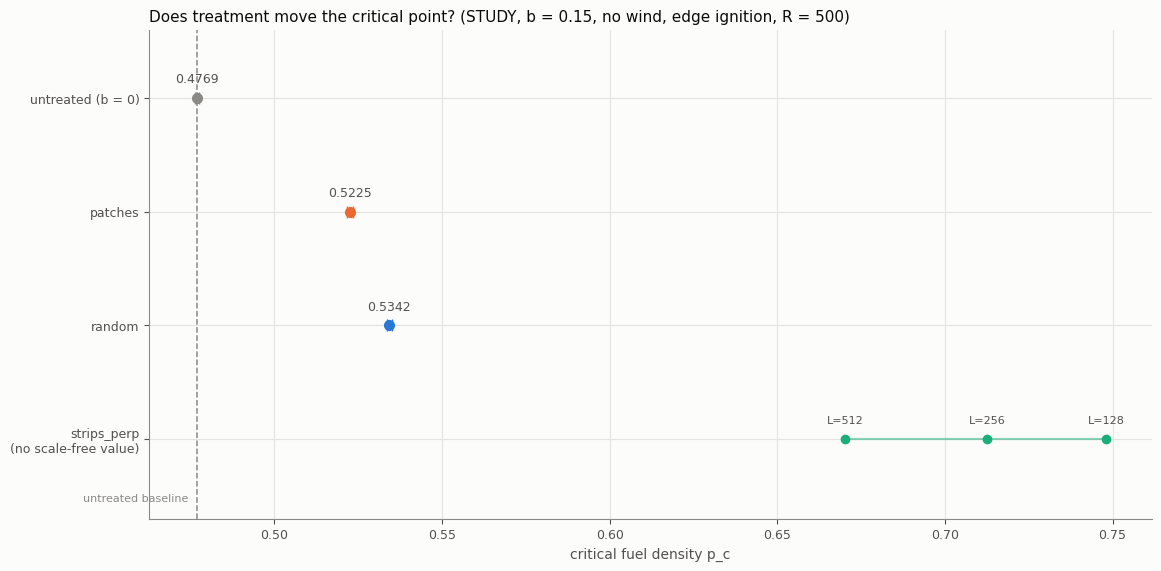

In [3]:
fig = FIGURES["threshold-shift"]()
fig

In [4]:
display(Markdown("**Caption.** " + CAPTIONS["threshold-shift"]))

**Caption.** Measured critical fuel density p_c of each treated landscape at b = 0.15, against the untreated STUDY baseline (Experiment 0b, kappa = 0). Bars are +/- 1 bootstrap standard error on the finite-size-scaling crossing across L in {128, 256, 512}, R = 500. `random` and `patches(4)` have a crossing, so a single threshold; `strips_perp(4)` has none, because its curves do not cross: its 50% spanning point falls steadily with lattice size, so the three per-L points are shown instead and no single value is quoted (DEC-041). Every threshold here is a STUDY value; the PERCOLATION validation threshold is a different quantity and never appears alongside these (project-context.md §10.1 D5).

**Treatment moves the critical point, so the answer to the primary research question is a change in the critical point, not only in amplitude.** At a 15% budget, scattering the treatment raises the critical fuel density from 0.477 to 0.534, and clumping it into 4 × 4 patches raises it to 0.523. Both shifts are around 0.05 in fuel density and both are enormous relative to their uncertainty, which is about 0.0004.

The ordering matches notebook 02: `random` buys slightly more threshold shift than `patches` for the same budget, because scattered treatment interrupts more potential paths than the same cells concentrated into blocks.

In [5]:
strips = scale[(scale.condition == "strips_perp") & np.isclose(scale.b, 0.15)].sort_values("L")
strips[["L", "p50", "p50_stderr", "n_per_point"]].set_index("L").round(4)

,p50,p50_stderr,n_per_point
L,,,
128,0.7481,0.0044,500
256,0.7126,0.0017,500
512,0.6702,0.0030,500


**`strips_perp` has no single critical point, and that is a result rather than a gap in the data.** Its spanning curves for the three lattice sizes never cross, so the finite-size-scaling estimator correctly refuses to return a value. What it has instead is a density at which half the fires span that *falls steadily with lattice size*: 0.748, 0.713, 0.670 at L = 128, 256, 512, and about 0.628 at L = 1024 in a separate probe.

The mechanism is specific to strips. A strip stops a fire only if the fire fails to break through it **anywhere along its length**. Doubling the lattice doubles the length of every strip and so roughly doubles the number of independent chances the fire has to find a weak point, while the spacing between strips stays fixed. The treatment therefore has a built-in length scale that does not grow with the system, which is exactly the condition under which finite-size scaling does not apply.

So strips raise the critical density by far more than any other arrangement at any size we can afford to run — by 0.15 to 0.27 against the untreated 0.477 — but that advantage is a function of how large the landscape is relative to the strip spacing, and it should not be quoted as a single number. This is recorded as DEC-041.

## 2. Burn-size distributions

Sub-question 3 asks whether treatment **truncates** the tail of the fire-size distribution or **changes its exponent**. These are different physical statements: truncation means the very largest fires become impossible while the rest of the distribution is unchanged; an exponent change means large fires become rarer at every size.

Telling them apart requires fitting a power law *with* a cutoff term, since a fit without one cannot distinguish the two. Experiment 2b ran 10,000 fires per condition at each condition's own critical point, where a heavy tail should be most visible.

In [6]:
fits[["condition", "p", "x_min", "n_tail", "alpha", "alpha_stderr", "cutoff",
      "decades_above_xmin", "ks_distance", "ks_critical", "fit_rejected"]].set_index("condition").round(4)

,p,x_min,n_tail,alpha,alpha_stderr,cutoff,decades_above_xmin,ks_distance,ks_critical,fit_rejected
condition,,,,,,,,,,
none,0.4769,1,10000,0.6680,0.0053,21530.1161,4.4068,0.1171,0.0136,1.0
random,0.5342,252,7424,0.0848,0.0188,10269.3883,2.0018,0.1179,0.0158,1.0
patches,0.5225,194,7314,0.2077,0.0172,9730.0615,2.0855,0.0994,0.0159,1.0


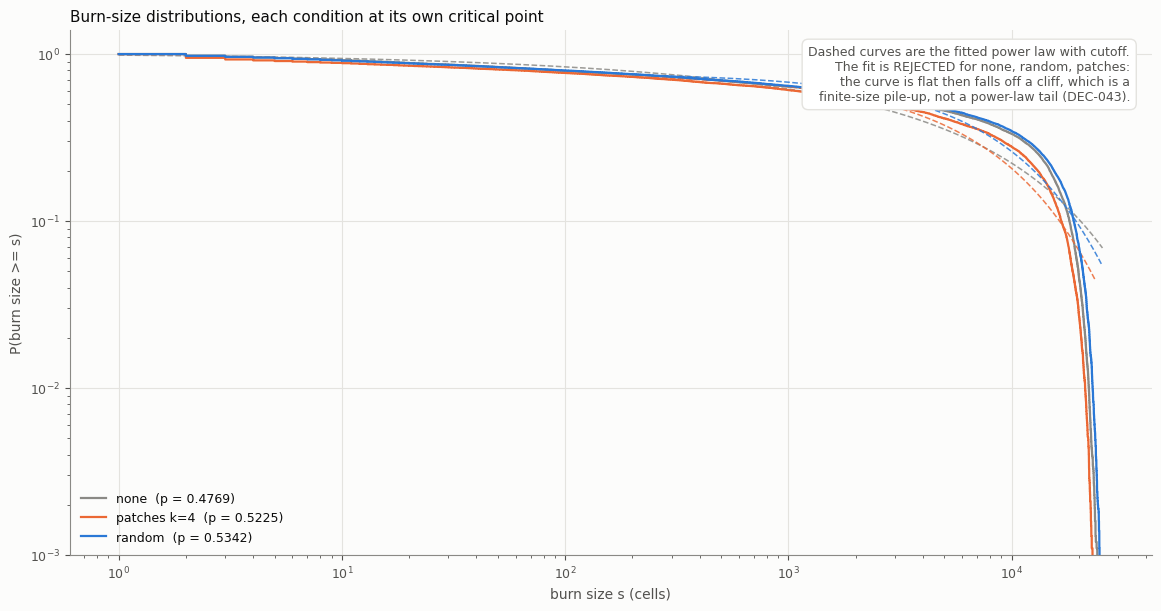

In [7]:
fig = FIGURES["burn-size-distributions"]()
fig

In [8]:
display(Markdown("**Caption.** " + CAPTIONS["burn-size-distributions"]))

**Caption.** Burn-size distributions at each condition's own critical point (Experiment 2b, STUDY, L = 256, one random ignition, no settlement, R = 10,000). Survival function P(X >= s) on log-log axes; a straight line would be a power law. Dashed curves are the fitted power law with exponential cutoff. **The fit is rejected for every condition**: each KS distance is about eight times its 5% critical value, because at a critical point on a finite lattice the distribution is a shallow power law followed by a pile-up of fires that span the lattice, which no monotonically decaying model represents. No exponent or cutoff from this figure may be quoted as a measured value (DEC-043). What the figure does show is that the distributions differ between conditions.

**The fitted model is rejected for every condition, and the reason is physical rather than statistical.** Each fitted curve spans more than the two decades the protocol asks for, so the gate on tail length passes. But the goodness-of-fit test fails decisively: each KS distance is roughly eight times its 5% critical value.

The figure shows why. The survival curve is almost flat out to several thousand cells and then falls off a cliff. That is not a power law with a cutoff, which would bend smoothly. It is a shallow power law followed by a **pile-up of fires that span the lattice**: at a critical point on a finite landscape, a third of untreated fires burn more than 10,000 of the 65,536 cells. No monotonically decaying model can represent a distribution with a bump in it.

More replicates would not help, because the problem is the shape of the distribution rather than the precision with which it is measured. The fitter itself is sound: run on the same condition at fuel densities *below* its critical point it fits well, and the fitted cutoff grows as the critical point is approached — 269, 648 and 2,867 cells at 0.06, 0.04 and 0.02 below threshold — which is the expected critical scaling.

**So SQ3 is answered qualitatively, not with fitted exponents.** The distributions do differ between arrangements: a two-sample test separates every pair, and `patches` produces visibly smaller fires than untreated even though it runs at a higher fuel density. But no exponent or cutoff from this experiment should be quoted as a measured value. This is recorded as DEC-043, along with a recommendation to add a sub-critical arm where the fit is valid.

## 3. Wind interaction

Sub-question 1 asks whether the ranking of arrangements depends on the wind. Experiment 3 ran every arrangement at four wind strengths, each at the untreated threshold **of that same wind strength** plus 0.05, so every point sits at a comparable distance from its own critical point rather than at a fixed fuel density.

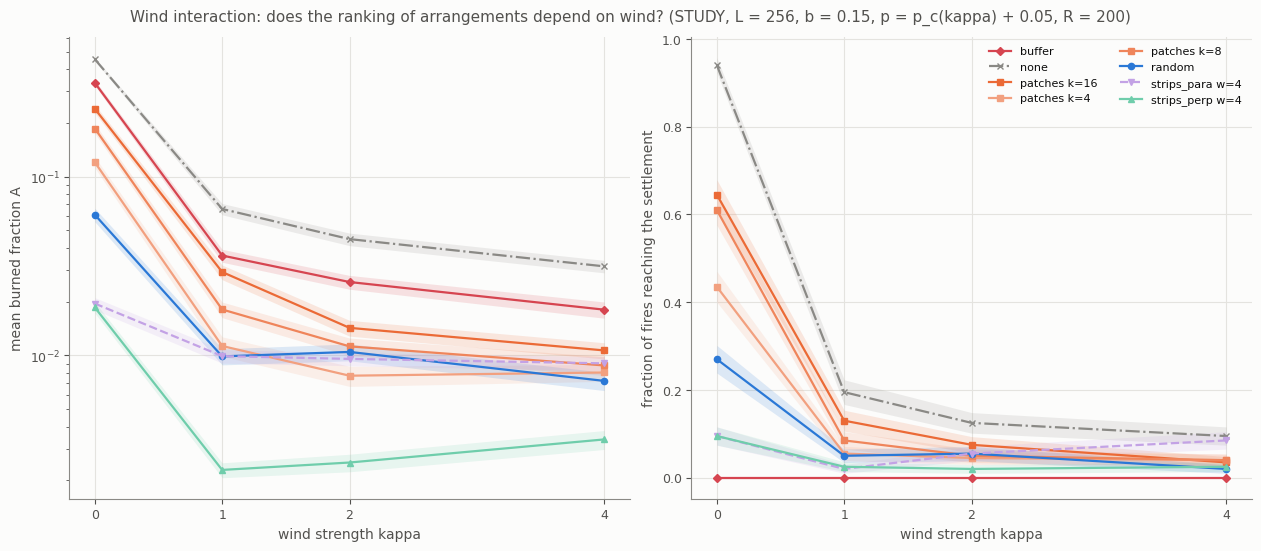

In [9]:
fig = FIGURES["wind-interaction"]()
fig

In [10]:
display(Markdown("**Caption.** " + CAPTIONS["wind-interaction"]))

**Caption.** Experiment 3: is the ranking of treatment arrangements wind-dependent (SQ1)? Mean burned fraction (left) and the fraction of fires reaching the settlement (right) against wind strength kappa, each arrangement at b = 0.15 and at the untreated threshold of that same kappa plus 0.05, so every point sits at a comparable distance from its own critical point. L = 256, 200 replicates per point, bands are +/- 1 standard error. Strips across the wind are best at every wind strength, and the gap to strips along the wind widens as wind strengthens; the middle of the ranking does reorder.

In [11]:
exp3 = pd.read_parquet(ROOT / "results" / "exp3.parquet",
                       columns=["condition", "geometry_params", "kappa", "burned_fraction"])
import json
exp3["level"] = [c if c in ("none", "random", "buffer") else
                 f"{c} {'k' if c == 'patches' else 'w'}={json.loads(g).get('k', json.loads(g).get('w'))}"
                 for c, g in zip(exp3.condition, exp3.geometry_params)]
ranks = (exp3[exp3.condition != "none"].groupby(["level", "kappa"]).burned_fraction.mean()
         .unstack().rank().astype(int))
ranks.columns.name = "wind strength kappa"
ranks

wind strength kappa,0.0,1.0,2.0,4.0
level,,,,
buffer,7,7,7,7
patches k=16,6,6,6,6
patches k=4,4,4,2,3
patches k=8,5,5,5,4
random,3,2,4,2
strips_para w=4,2,3,3,5
strips_perp w=4,1,1,1,1


**The extremes are stable and the middle reorders, so the answer to SQ1 is a qualified yes.**

`strips_perp` is the best arrangement at every wind strength and `buffer` the worst for landscape burning at every wind strength, so the headline ranking is not a wind artefact. But the middle of the table moves: `strips_para` is second best with no wind and fifth at the strongest wind, while `random` improves as wind strengthens.

The orientation contrast is the clearest wind effect, and it is the one the design was built to isolate. With no wind, strips across and strips along the spread direction perform identically, as they must by symmetry — 0.0185 against 0.0195, well within noise. As wind strengthens they separate, and at the strongest wind strips across the wind burn roughly a third as much as the same strips rotated 90°. Same shape, same budget, different orientation, different outcome.

## 4. Sensitivity

Several parameters were fixed by judgement rather than measured: the base spread probability β at 0.8, and the fuel load of a treated cell at 0.2. Experiment 4 reruns a reduced condition set across β ∈ {0.7, 0.8, 0.9} and treated fuel load ∈ {0, 0.2, 0.4}.

Every one of its 9,000 runs sits at a **single** fuel density, held fixed across all nine cells, so the landscape does not move when β does. That is deliberate: the check asks how outcomes shift when spread strength changes on the same landscape.

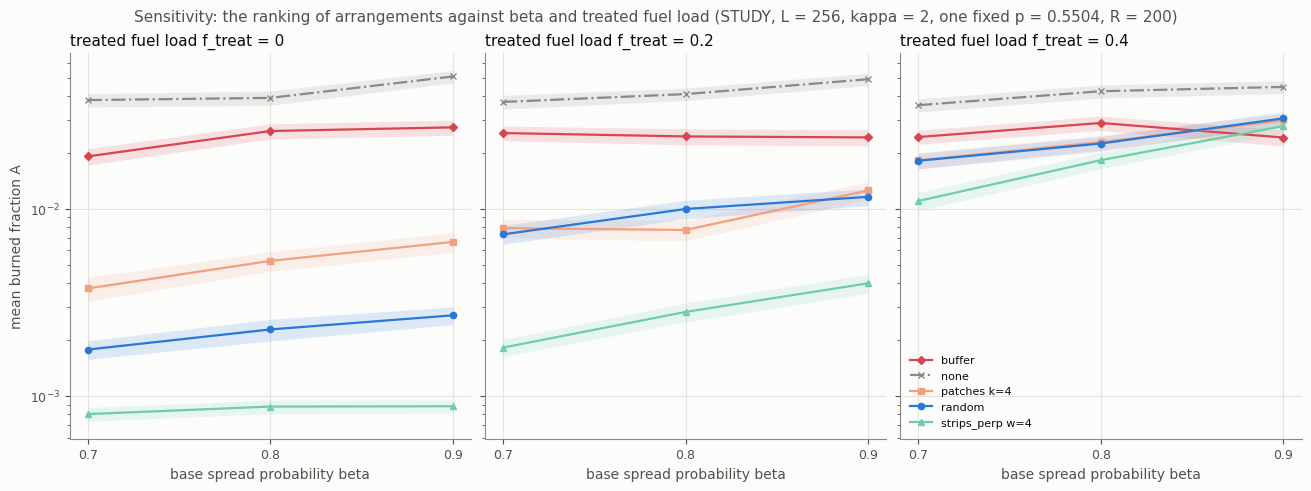

In [12]:
fig = FIGURES["sensitivity"]()
fig

In [13]:
display(Markdown("**Caption.** " + CAPTIONS["sensitivity"]))

**Caption.** Experiment 4: do the conclusions survive the parameter choices? Mean burned fraction against the base spread probability beta, one panel per treated-fuel load f_treat, with the reduced condition set. All 9,000 runs sit at a single absolute fuel density p = 0.5504, the kappa = 2 untreated threshold plus 0.05, held fixed across every cell so the landscape does not move with beta (DEC-011). L = 256, 200 replicates per point, bands are +/- 1 standard error. The ranking of arrangements is unchanged across beta, so it is not an artefact of fixing beta at 0.8; f_treat matters more, and at f_treat = 0.4 the arrangements converge, because treated fuel that still burns readily stops acting as a break.

In [14]:
exp4 = pd.read_parquet(ROOT / "results" / "exp4.parquet",
                       columns=["condition", "beta", "f_treat", "burned_fraction", "p", "p_rel"])
assert exp4.p.nunique() == 1 and exp4.p_rel.isna().all()
order = (exp4[exp4.condition != "none"].groupby(["condition", "beta", "f_treat"])
         .burned_fraction.mean().unstack(["beta", "f_treat"]).rank().astype(int))
print(f"all {len(exp4):,} runs at a single p = {exp4.p.iloc[0]:.4f}")
order

all 9,000 runs at a single p = 0.5504


beta        0.7         0.8         0.9        
f_treat     0.0 0.2 0.4 0.0 0.2 0.4 0.0 0.2 0.4
condition                                      
buffer        4   4   4   4   4   4   4   4   1
patches       3   3   3   3   2   3   3   3   3
random        2   2   2   2   3   2   2   2   4
strips_perp   1   1   1   1   1   1   1   1   2

**The ranking of arrangements is unchanged by β, so the conclusions are not an artefact of fixing it at 0.8.** `strips_perp` is first and `buffer` last in eight of the nine cells, and the single exception is the most extreme corner, where spread is easiest and treated fuel still burns readily.

The treated fuel load matters much more than β. At a load of 0 — complete fuel removal — the arrangements are separated by more than an order of magnitude. At 0.4 they converge: treated fuel that still burns reasonably well stops acting as a barrier at all, and at that point arrangement barely matters. That is a more interesting sensitivity result than β, because it says the effectiveness of *any* spatial arrangement depends on actually reducing fuel enough, not on where the reduction goes.

## 5. The lattice frame-invariance check

The strips run along the lattice axes, and so does the wind in the main experiments. A square lattice is not isotropic, so part of the measured advantage of strips across the wind might be an artefact of that alignment rather than a real geometric effect.

This was planned for in advance as a single check rather than an experimental axis: measure the gap between the two strip orientations with the wind on an axis, then again with the wind on the diagonal and the geometry rotated to match.

In [15]:
import math

from src.experiments import i11_gaps          # the gap calculation, not a simulation

i11 = pd.read_parquet(ROOT / "results" / "i11_frame.parquet")
gaps = i11_gaps(i11)
display(gaps.round(5))
print(f"difference between the two gaps: {gaps.attrs['difference']:+.5f} "
      f"+/- {gaps.attrs['difference_stderr']:.5f}")
print("95% intervals overlap:", gaps.attrs["overlap"])

,phi,gap,gap_stderr,ci_lo,ci_hi,n_per_condition
0,0.0000,-0.00884,0.00090,-0.01062,-0.00707,200
1,0.7854,-0.00448,0.00058,-0.00561,-0.00335,200


difference between the two gaps: -0.00436 +/- 0.00107
95% intervals overlap: False


**The check did not pass, and the magnitude is the result.** The advantage of strips across the wind over strips along it is about twice as large when the strips lie on the lattice axes (a gap of 0.0088 in burned fraction) as when they run diagonally (0.0045). The two intervals do not overlap and the difference is roughly four standard errors.

What survives rotation is the **conclusion**: strips across the wind beat strips along it at both wind angles, significantly in both cases. What does not survive is the **size** of that advantage, which is inflated by roughly a factor of two when the geometry is axis-aligned.

This belongs in Limitations with its magnitude attached, which is one of the two outcomes the design planned for. It means the orientation effect is real but should not be quoted to better than about a factor of two, and that a hexagonal or off-axis lattice would be the way to measure it cleanly.

## 6. Limitations

The limitations the report should carry, in rough order of how much they constrain the conclusions.

**Wind redirects spread without intensifying it.** The direction weights are normalised to average 1, so increasing wind strength changes where a fire spreads but not how flammable the landscape is. This keeps wind and flammability identifiable as separate effects, which is why the design does it, but it means absolute burned areas under wind are not realistic: in this model stronger wind produces *smaller* fires, because the fire loses more sideways and upwind spread than it gains downwind. Wind results here are about the direction of spread, not about fire danger.

**The strips result is landscape-size-dependent.** `strips_perp` has no scale-free critical density. Its advantage shrinks as the landscape grows relative to the spacing between strips, and the data do not settle where it converges. Any claim about strips should state the lattice size it was measured at.

**The orientation advantage is partly a lattice artefact,** inflated by about a factor of two when strips lie on the lattice axes, as section 5 measures.

**No fitted tail exponents.** At the operating point the protocol specified, the power-law-with-cutoff model is rejected, so SQ3 is answered by comparing distributions rather than by fitted parameters.

**The settlement metric is right-censored.** Time-to-reach is only defined for fires that reached the settlement, and for the best arrangements that is a small, fast, unrepresentative group. It must be read alongside the probability of reaching at all.

**Parameters chosen by judgement.** β = 0.8 and a treated fuel load of 0.2 were not calibrated to fire data. Section 4 shows the ranking is robust to β, but the treated fuel load matters a great deal, and a real prescribed burn does not reduce fuel by a single fixed factor everywhere.

**One fire per landscape, no regrowth.** Each run is a single fire on a freshly generated landscape. There is no fuel accumulation between seasons and no treatment decay, so nothing here speaks to how a treatment programme performs over time — which is the question a land manager would actually ask, and the most natural extension of this work.

**A square lattice with eight-neighbour spread is a caricature of fire.** There is no topography, no fuel types, no spotting, no suppression. The result is a statement about critical phenomena in a spatially structured medium, not a prediction of fire behaviour.